In [1]:
import xarray as xr
import matplotlib.pyplot as plt

In [13]:
var="snowfall"
ds = xr.open_dataset(f"/home/nld4814/scratch/FGRN055_era055/raw/{var}.KNMI-2021.FGRN055_R23p2.BN_RACMO2.3p2_ERA5_3h_1940_FGRN055.3H.nc")

In [14]:
ds.time

<xarray.DataArray 'time' (time: 14608)> Size: 117kB
array(['2021-01-01T00:00:00.000000000', '2021-01-01T03:00:00.000000000',
       '2021-01-01T06:00:00.000000000', ..., '2025-12-31T15:00:00.000000000',
       '2025-12-31T18:00:00.000000000', '2025-12-31T21:00:00.000000000'],
      shape=(14608,), dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 117kB 2021-01-01 ... 2025-12-31T21:00:00
Attributes:
    axis:       T
    long_name:  time
    dtgstart:   2021010100
    bounds:     time_bnds

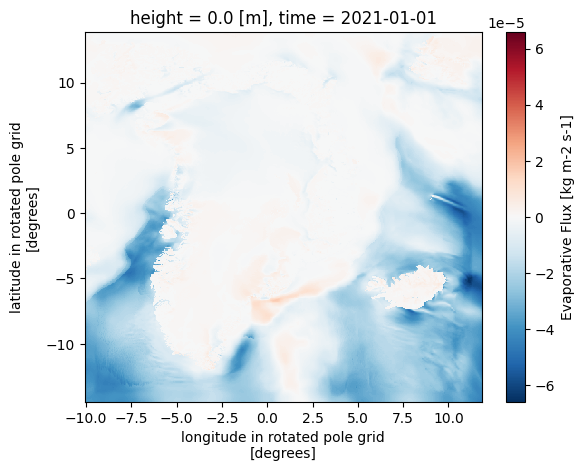

In [8]:
ds.evap.isel(time=0).plot()

<xarray.DataArray 'time' (time: 14608)> Size: 117kB
array(['2021-01-01T00:00:00.000000000', '2021-01-01T03:00:00.000000000',
       '2021-01-01T06:00:00.000000000', ..., '2025-12-31T15:00:00.000000000',
       '2025-12-31T18:00:00.000000000', '2025-12-31T21:00:00.000000000'],
      shape=(14608,), dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 117kB 2021-01-01 ... 2025-12-31T21:00:00
Attributes:
    axis:       T
    long_name:  time
    dtgstart:   2021010100
    bounds:     time_bnds

In [4]:
# check difference between 1958 files for old racmo years

ds1957 = xr.open_dataset("/home/nld4814/scratch/FGRN055_era055/process-RACMO/years-1957/evap_FGRN055_era055_forFDM_Year1960.nc")
ds1939 = xr.open_dataset("/home/nld4814/scratch/FGRN055_era055/process-RACMO/years-1939/evap_FGRN055_era055_forFDM_Year1960.nc")

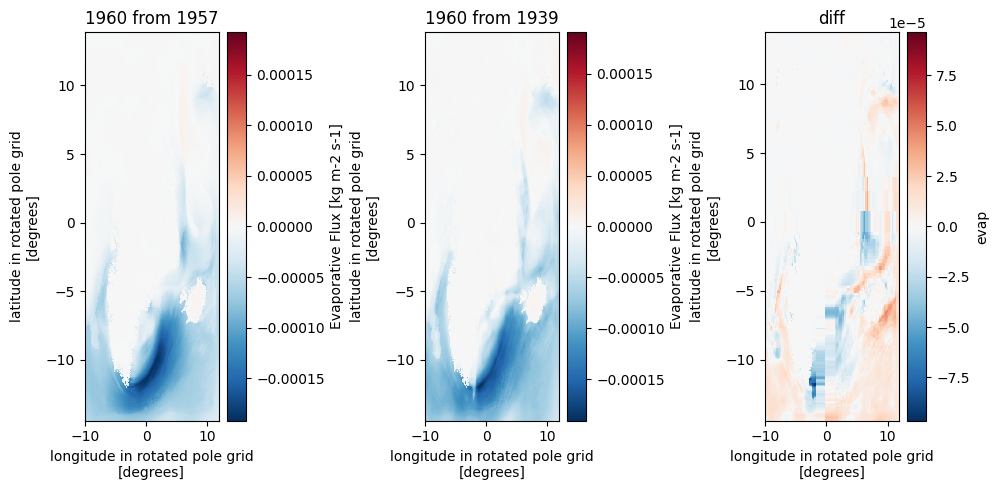

In [10]:
fig, axs = plt.subplots(1,3,figsize=(10,5))

ds1957.evap.isel(time=0).plot(ax=axs[0])
axs[0].set_title("1960 from 1957")
ds1939.evap.isel(time=0).plot(ax=axs[1])
axs[1].set_title("1960 from 1939")

(ds1957.evap.isel(time=0)-ds1939.evap.isel(time=0)).plot(ax=axs[2])
axs[2].set_title("diff")
plt.tight_layout()

In [21]:
# check years look good before dividing

# check extended parts look good before concatenating
var = "ff10m"
ds_year2024 = xr.open_dataset(f"/home/nld4814/scratch/FGRN055_era055/process-RACMO/years-1939/{var}_FGRN055_era055_forFDM_Year2024.nc")
ds_year2023 = xr.open_dataset(f"/home/nld4814/scratch/FGRN055_era055/process-RACMO/years-1939/{var}_FGRN055_era055_forFDM_Year2023.nc")

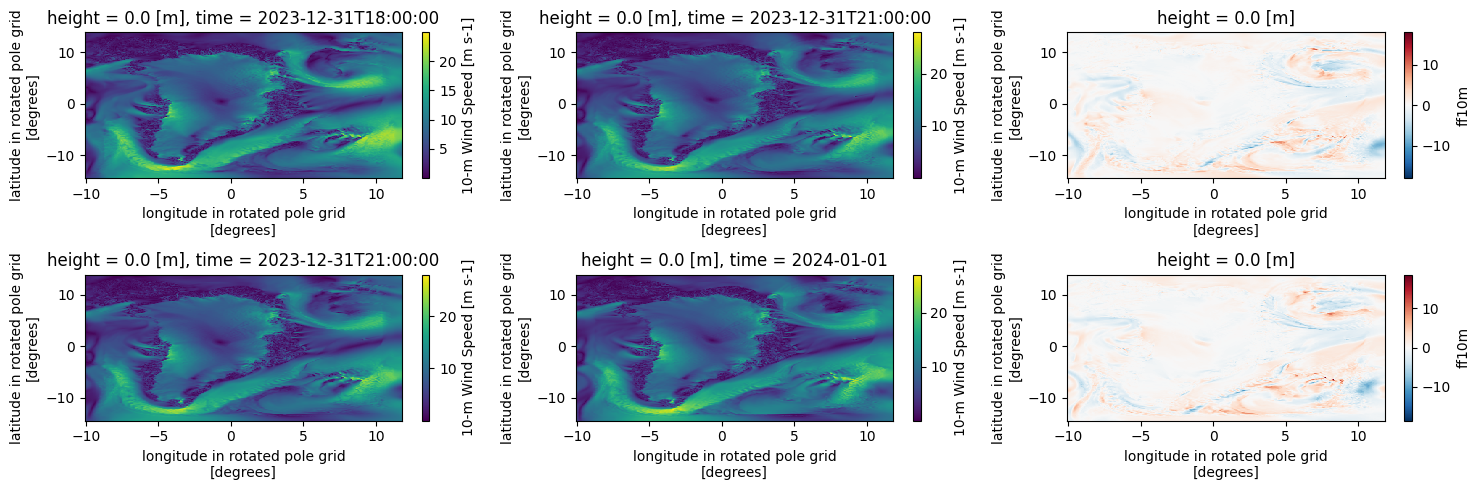

In [ ]:
fig, axs = plt.subplots(2,3,figsize=(15,10))


ds_year2023[var].isel(time=2918).plot(ax=axs[0,0])
ds_year2023[var].isel(time=2919).plot(ax=axs[0,1])
(ds_year2023[var].isel(time=2919)-ds_year2023[var].isel(time=2918)).plot(ax=axs[0,2])

ds_year2023[var].isel(time=2919).plot(ax=axs[1,0])
ds_year2024[var].isel(time=0).plot(ax=axs[1,1])
(ds_year2024[var].isel(time=0)-ds_year2023[var].isel(time=2919)).plot(ax=axs[1,2])

plt.tight_layout()

(np.float64(19692.0), np.float64(19753.0))

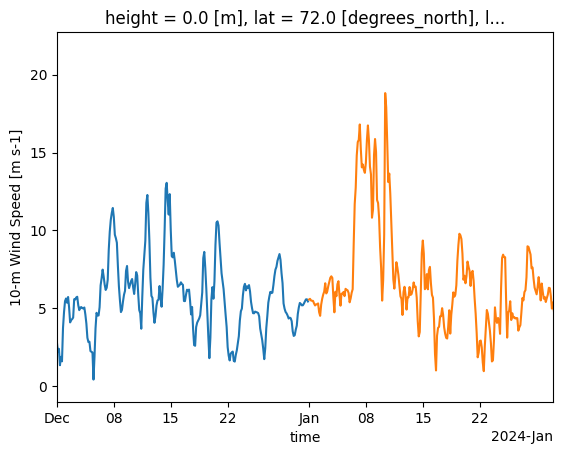

In [29]:
from datetime import datetime

ds_year2023[var].sel(rlat=0,rlon=0).plot()
ds_year2024[var].sel(rlat=0,rlon=0).plot()

plt.gca().set_xlim(datetime(2023,12,1),datetime(2024,1,31))

In [19]:
# check extended parts look good before concatenating
var = "ff10m"
ds_part2024 = xr.open_dataset(f"/home/nld4814/scratch/FGRN055_era055/process-RACMO/years-1939/parts_extend/{var}_2024_part1.nc")
ds_part2023 = xr.open_dataset(f"/home/nld4814/scratch/FGRN055_era055/process-RACMO/years-1939/parts/{var}_2023_part1.nc")

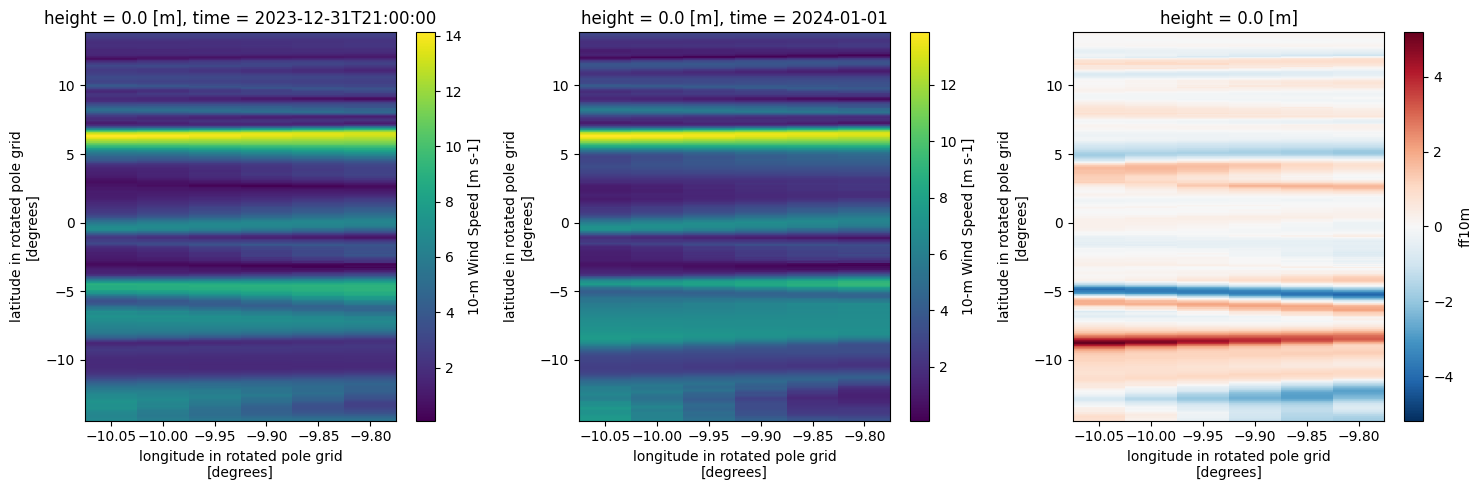

In [20]:
fig, axs = plt.subplots(1,3,figsize=(15,5))

ds_part2023[var].isel(time=2919).plot(ax=axs[0])
ds_part2024[var].isel(time=0).plot(ax=axs[1])
(ds_part2024[var].isel(time=0)-ds_part2023[var].isel(time=2919)).plot(ax=axs[2])

plt.tight_layout()

In [4]:
# check new parts

ds_new = xr.open_dataset("/home/nld4814/scratch/FGRN055_era055/input/timeseries/precip_FGRN055_era055_1939-2025_p19.nc")
ds_new

<xarray.Dataset> Size: 3GB
Dimensions:       (time: 252272, nblock1: 40, nblock2: 400, bnds: 2, rlat: 566,
                   rlon: 6, height: 1)
Coordinates:
  * time          (time) datetime64[ns] 2MB 1939-09-01 ... 2025-12-31T21:00:00
  * rlat          (rlat) float64 5kB -14.4 -14.35 -14.3 ... 13.75 13.8 13.85
  * rlon          (rlon) float64 48B -4.65 -4.6 -4.55 -4.5 -4.45 -4.4
  * height        (height) float64 8B 0.0
    lat           (rlat, rlon) float64 27kB ...
    lon           (rlat, rlon) float64 27kB ...
Dimensions without coordinates: nblock1, nblock2, bnds
Data variables:
    assigned      (time) int32 1MB ...
    block1        (nblock1) int32 160B ...
    block2        (nblock2) int32 2kB ...
    date_bnds     (time, bnds) int32 2MB ...
    dir           (rlat, rlon) float64 27kB ...
    dtg           (time) int32 1MB ...
    hms_bnds      (time, bnds) int32 2MB ...
    precip        (time, height, rlat, rlon) float32 3GB ...
    rotated_pole  float32 4B ...
    time_bnds     (time, bnds) datetime64[ns] 4MB ...
Attributes:
    Conventions:   CF-1.4
    source:        RACMO2
    Domain:        FGRN055
    Experiment:    BN_RACMO2.3p2_ERA5_3h_1940_FGRN055
    institution:   Royal Netherlands Meteorological Institute (KNMI)
    CreationDate:  Tue Apr 11 19:37:55 2023
    comment:       asim2cdf: cpar=precip, iwmo=61, ilvt=105, ilev=0, idh=3, i...
    title:         Total Precipitative Flux
    history:       Thu Apr  9 13:42:52 2026: ncrcat /ec/res4/scratch/nld4814/...
    NCO:           netCDF Operators version 5.3.2 (Homepage = http://nco.sf.n...

In [2]:
# check concatenation worked

ds = xr.open_dataset("/home/nld4814/scratch/FGRN055_era055/input/timeseries/evap_FGRN055_era055_1939-2025_p1.nc")

ds

<xarray.Dataset> Size: 3GB
Dimensions:       (time: 252272, nblock1: 40, nblock2: 400, bnds: 2, rlat: 566,
                   rlon: 6, height: 1)
Coordinates:
  * time          (time) datetime64[ns] 2MB 1939-09-01 ... 2025-12-31T21:00:00
  * rlat          (rlat) float64 5kB -14.4 -14.35 -14.3 ... 13.75 13.8 13.85
  * rlon          (rlon) float64 48B -10.05 -10.0 -9.95 -9.9 -9.85 -9.8
  * height        (height) float64 8B 0.0
    lat           (rlat, rlon) float64 27kB ...
    lon           (rlat, rlon) float64 27kB ...
Dimensions without coordinates: nblock1, nblock2, bnds
Data variables:
    assigned      (time) int32 1MB ...
    block1        (nblock1) int32 160B ...
    block2        (nblock2) int32 2kB ...
    date_bnds     (time, bnds) int32 2MB ...
    dir           (rlat, rlon) float64 27kB ...
    dtg           (time) int32 1MB ...
    evap          (time, height, rlat, rlon) float32 3GB ...
    hms_bnds      (time, bnds) int32 2MB ...
    rotated_pole  float32 4B ...
    time_bnds     (time, bnds) datetime64[ns] 4MB ...
Attributes:
    Conventions:   CF-1.4
    source:        RACMO2
    Domain:        FGRN055
    Experiment:    BN_RACMO2.3p2_ERA5_3h_1940_FGRN055
    institution:   Royal Netherlands Meteorological Institute (KNMI)
    CreationDate:  Tue Apr 11 19:37:55 2023
    comment:       asim2cdf: cpar=evap, iwmo=182, ilvt=105, ilev=0, idh=3, ih...
    title:         Evaporative Flux
    history:       Thu Apr  9 13:09:51 2026: ncrcat /ec/res4/scratch/nld4814/...
    NCO:           netCDF Operators version 5.3.2 (Homepage = http://nco.sf.n...

In [ ]:
# check antarctic data
ds = xr.open_dataset("/ec/res4/scratch/nld3442/experiment/ANT27/ERA5-3H_RACMO2.3p2-2021/NC_3H/ff10m.KNMI-2021.ANT27.ERA5-3H_RACMO2.3p2.3H.nc")

ds.time

<xarray.DataArray 'time' (time: 14608)> Size: 117kB
array(['2021-01-01T00:00:00.000000000', '2021-01-01T03:00:00.000000000',
       '2021-01-01T06:00:00.000000000', ..., '2025-12-31T15:00:00.000000000',
       '2025-12-31T18:00:00.000000000', '2025-12-31T21:00:00.000000000'],
      shape=(14608,), dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 117kB 2021-01-01 ... 2025-12-31T21:00:00
Attributes:
    axis:       T
    long_name:  time
    dtgstart:   2021010100
    bounds:     time_bnds

In [5]:
# look at restart files

ds = xr.open_dataset("/home/nld4814/scratch/restart/run_FGRN055-era055_1939-2023/FGRN055_era055_initialize_from_2023_run_50893.nc")

ds

<xarray.Dataset> Size: 115kB
Dimensions:   (layer: 3609, constant: 1)
Dimensions without coordinates: layer, constant
Data variables:
    dens      (layer) float32 14kB ...
    temp      (layer) float32 14kB ...
    mass      (layer) float32 14kB ...
    depth     (layer) float32 14kB ...
    lwc       (layer) float32 14kB ...
    year      (layer) float32 14kB ...
    refreeze  (layer) float32 14kB ...
    denrho    (layer) float32 14kB ...
    prev_nt   (constant) float32 4B ...

In [6]:
# check antartic restart files
ds = xr.open_dataset("/ec/res4/scratch/nld4814/ANT27_ERA5/ECMWF_ANT27_ERA5_1979_restart_9_1.nc")

In [7]:
ds

<xarray.Dataset> Size: 720kB
Dimensions:      (layer: 20000, constant: 1)
Dimensions without coordinates: layer, constant
Data variables: (12/24)
    dens         (layer) float32 80kB ...
    temp         (layer) float32 80kB ...
    mass         (layer) float32 80kB ...
    depth        (layer) float32 80kB ...
    lwc          (layer) float32 80kB ...
    year         (layer) float32 80kB ...
    ...           ...
    totrunoff    (constant) float32 4B ...
    totrefreeze  (constant) float32 4B ...
    totrain      (constant) float32 4B ...
    totsurfmelt  (constant) float32 4B ...
    totsolin     (constant) float32 4B ...
    rho0out      (constant) float32 4B ...

In [16]:
ds.kUL.values

array([3854], dtype=int32)